# 03 – Baseline Model and Model Comparison

**Project:** AI-Powered Project Planning & Risk Forecasting Platform

This notebook develops and compares machine learning models to predict **task-level risk classifications**.

---

## Objectives

1. Establish a **baseline model** for comparison  
2. Train multiple machine learning models  
3. Evaluate model performance using multiple metrics  
4. Select the best model based on **cross-validated performance**  

---

## Target Variable

**Risk_Level**

This represents the risk classification of individual tasks in the project.

---

## Models Evaluated

- Most Frequent Dummy Classifier (baseline)  
- Logistic Regression  
- Random Forest  
- Extra Trees  
- HistGradientBoosting  

---

## Evaluation Metrics

- Accuracy  
- Macro F1 Score  
- Weighted F1 Score  
- Cross-Validated Macro F1  

**Note:** Model selection is based primarily on **cross-validated Macro F1**, not accuracy alone.

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting & preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

## Load Dataset

The **task-level dataset** is used for machine learning modeling.

This dataset (`construction_dataset.csv`) contains task-level features such as:

- labor requirements  
- equipment usage  
- resource constraints  

along with the target variable:

- `Risk_Level`

This dataset is specifically used for **training and evaluating risk prediction models**.

In [2]:
construction_df = pd.read_csv("../data/construction_dataset.csv")

construction_df.head()

,Task_ID,Task_Duration_Days,Labor_Required,Equipment_Units,Material_Cost_USD,Start_Constraint,Risk_Level,Resource_Constraint_Score,Site_Constraint_Score,Dependency_Count
0,T1,52,14,6,16789.73,0,Medium,0.41,0.59,4
1,T2,15,2,2,16885.80,5,Low,0.75,0.17,3
2,T3,72,11,1,7978.70,22,Low,0.96,0.41,1
3,T4,61,1,5,19379.02,18,Low,0.41,0.67,4
4,T5,21,19,5,66757.72,22,Low,0.85,0.63,3


## Define the Target Variable

The target for this notebook is:

**`Risk_Level`**

This variable represents the risk classification of individual tasks within a project.

Predicting this label enables:

- early identification of high-risk tasks  
- better allocation of resources  
- proactive risk mitigation during project execution  

This forms the core predictive component of the system.

In [3]:
target = "Risk_Level"

## Encode the Target Variable

Machine learning models require the target variable to be represented numerically.

The `Risk_Level` variable is categorical (e.g., Low, Medium, High), so it is encoded into numerical labels.

This allows models to process and learn from the target variable effectively.

In [4]:
encoder = LabelEncoder()

construction_df[target] = encoder.fit_transform(construction_df[target])

# Preview encoded values
construction_df[target].head()

# Show mapping (important for interpretation)
dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

## Select Input Features

The input features are used to predict **task-level risk**.

The selected features describe key aspects of project execution, including:

- resource requirements  
- equipment usage  
- task complexity  
- resource constraints  

These variables are chosen because they are available **before task execution**, ensuring that predictions can be made in advance without information leakage.

This is critical for building a realistic and deployable model.

In [5]:
features = [
    "Labor_Required",
    "Equipment_Units",
    "Resource_Constraint_Score"
]

X = construction_df[features]
y = construction_df[target]

## Train/Test Split

To evaluate model performance properly, the dataset is split into:

- a **training set** for learning patterns  
- a **test set** for evaluating generalization  

The **stratified sampling** is used to preserve the distribution of risk classes across both sets.

This ensures that model evaluation is reliable and representative.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(Risk_Level
 1    0.507692
 2    0.290385
 0    0.201923
 Name: proportion, dtype: float64,
 Risk_Level
 1    0.507692
 2    0.288462
 0    0.203846
 Name: proportion, dtype: float64)

In [8]:
# Data Consistency Check

print("Train/Test Shapes:")
print(X_train.shape, X_test.shape)

print("\nClass Distribution:")
print("Train:", set(y_train))
print("Test:", set(y_test))

Train/Test Shapes:
(1040, 3) (260, 3)

Class Distribution:
Train: {0, 1, 2}
Test: {0, 1, 2}


## Train-Test Split

**Key Insight**

- The dataset is split into training and testing sets using stratification.
- Stratification ensures class distribution is preserved across both sets.
- This is important for imbalanced datasets to maintain reliable evaluation.

## Feature Scaling

Some models, particularly linear models such as Logistic Regression, are sensitive to feature scale.

To ensure proper model training, the input features are standardized using `StandardScaler`.

Tree-based models (e.g., Random Forest, Extra Trees, HistGradientBoosting) do not require scaling, but it is included to ensure consistency for scale-sensitive models.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = LogisticRegression()

# Train
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Baseline Model – Logistic Regression

**Logistic Regression** is used as the baseline model to establish a simple and interpretable benchmark for classification performance.

A baseline model is important because it provides a reference point against which more advanced models can be compared. If more complex models do not improve meaningfully over the baseline, their added complexity may not be justified.

Logistic Regression is a **linear classification model** that estimates class probabilities using a logistic function. Since it is sensitive to feature scale, **standardized features** (`X_train_scaled`, `X_test_scaled`) is used to ensure proper model training.

### Key Points

- Uses **scaled input features**
- Provides a **fast and interpretable baseline**
- Enables **fair comparison with more complex models**
- Supports evaluation using **Accuracy and Macro F1 score**

### Baseline Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Initialize model
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train model
log_model.fit(X_train_scaled, y_train)

# Predictions
log_predictions = log_model.predict(X_test_scaled)

# Evaluation
log_accuracy = accuracy_score(y_test, log_predictions)
log_f1 = f1_score(y_test, log_predictions, average="macro")

# Output
print(f"Baseline Logistic Regression Accuracy: {log_accuracy:.3f}")
print(f"Baseline Logistic Regression Macro F1: {log_f1:.3f}")

print("\nClassification Report (Baseline Model):\n")
print(classification_report(y_test, log_predictions, zero_division=0))

Baseline Logistic Regression Accuracy: 0.508
Baseline Logistic Regression Macro F1: 0.224

Classification Report (Baseline Model):

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        53
           1       0.51      1.00      0.67       132
           2       0.00      0.00      0.00        75

    accuracy                           0.51       260
   macro avg       0.17      0.33      0.22       260
weighted avg       0.26      0.51      0.34       260



## Baseline Logistic Regression Evaluation

**Key Insight**

- Logistic Regression achieves moderate overall accuracy (~0.51) on the test dataset.
- However, the Macro F1-score (~0.22) is low, indicating poor performance across classes.
- The model predicts almost exclusively the majority class (Class 1), achieving perfect recall (1.00) for that class.
- Minority classes (Classes 0 and 2) are not predicted at all, resulting in zero precision, recall, and F1-scores.
- This demonstrates a strong bias toward the majority class due to class imbalance.
- As a result, the model fails to identify higher-risk (minority) projects, making it unsuitable for reliable risk prediction.

### Balanced Logistic Regression

In [11]:
# Logistic Regression with Class Balancing

from sklearn.metrics import classification_report

log_model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model_balanced.fit(X_train_scaled, y_train)
log_predictions_balanced = log_model_balanced.predict(X_test_scaled)

log_accuracy_balanced = accuracy_score(y_test, log_predictions_balanced)
log_f1_balanced = f1_score(y_test, log_predictions_balanced, average="macro")

print(f"Balanced Logistic Regression Accuracy: {log_accuracy_balanced:.3f}")
print(f"Balanced Logistic Regression Macro F1: {log_f1_balanced:.3f}")

print("\nClassification Report (Balanced Model):\n")
print(classification_report(y_test, log_predictions_balanced, zero_division=0))

Balanced Logistic Regression Accuracy: 0.269
Balanced Logistic Regression Macro F1: 0.268

Classification Report (Balanced Model):

              precision    recall  f1-score   support

           0       0.17      0.34      0.23        53
           1       0.50      0.19      0.27       132
           2       0.26      0.36      0.30        75

    accuracy                           0.27       260
   macro avg       0.31      0.30      0.27       260
weighted avg       0.36      0.27      0.27       260



## Balanced Logistic Regression Evaluation

**Key Insight**

- The balanced Logistic Regression model achieves lower overall accuracy (~0.27) compared to the baseline model.
- However, the Macro F1-score (~0.27) improves, indicating more balanced performance across all classes.
- The model no longer focuses only on the majority class and begins to capture minority classes (Classes 0 and 2).
- Recall and F1-scores for minority classes improve, showing better detection of higher-risk projects.
- This reflects more effective handling of class imbalance through class weighting.
- Although overall accuracy decreases, the model provides more reliable and fair predictions across all risk levels.
- Therefore, the balanced Logistic Regression model is more suitable for this risk prediction task.

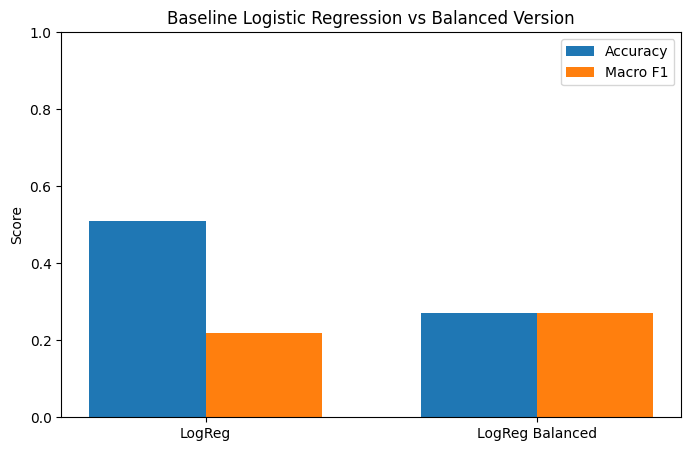

In [31]:
# Logistic Regression -> optimized for overall accuracy
# Balanced Logistic Regression -> optimized for class imbalance

import matplotlib.pyplot as plt
import numpy as np

models = ["LogReg", "LogReg Balanced"]
accuracy = [0.51, 0.27]
macro_f1 = [0.22, 0.27]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, macro_f1, width, label="Macro F1")

plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Baseline Logistic Regression vs Balanced Version")
plt.legend()

plt.show()

## Baseline Logistic Regression vs Balanced Version Evaluation

**Key Insight**

- Baseline Logistic Regression achieves higher accuracy (~0.51) but very low Macro F1 (~0.22).
- This indicates strong performance on the majority class but poor detection of minority (high-risk) classes.
- The Balanced Logistic Regression reduces accuracy (~0.27) but improves Macro F1 (~0.27).
- This shows a more even performance across all classes and better handling of class imbalance.
- The trade-off highlights that accuracy alone is misleading in imbalanced datasets.
- For this use case, the balanced model is more appropriate, as identifying high-risk projects is more important than maximizing overall accuracy.

## Random Forest Model

Next, a **Random Forest classifier** is trained as a more advanced model for project risk prediction.

Random Forest is an ensemble learning method that builds multiple decision trees and aggregates their predictions. It is well-suited for structured tabular data and can capture:

- **Nonlinear relationships**
- **Feature interactions**
- **Complex decision boundaries**

Unlike Logistic Regression, Random Forest is **not sensitive to feature scaling**, so the original (unscaled) features are used.

This model serves as a stronger benchmark to evaluate whether more flexible models improve performance over the baseline.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
     class_weight="balanced"
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions, average="macro")

# Output
print(f"Random Forest Accuracy: {rf_accuracy:.3f}")
print(f"Random Forest Macro F1: {rf_f1:.3f}")

print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, rf_predictions, zero_division=0))

Random Forest Accuracy: 0.373
Random Forest Macro F1: 0.291

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.16      0.13      0.15        53
           1       0.50      0.58      0.54       132
           2       0.21      0.17      0.19        75

    accuracy                           0.37       260
   macro avg       0.29      0.30      0.29       260
weighted avg       0.35      0.37      0.36       260



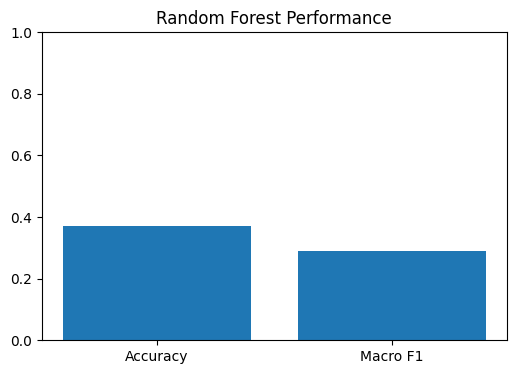

In [29]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Macro F1"]
values = [0.37, 0.29]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)

plt.ylim(0,1)
plt.title("Random Forest Performance")

plt.show()

## Random Forest Evaluation

**Key Insight**

- Random Forest achieves moderate accuracy (~0.37) and Macro F1 (~0.29).
- The model performs reasonably well on the majority class (Class 1).
- However, performance on minority classes (Classes 0 and 2) remains limited.
- The gap between Accuracy and Macro F1 highlights ongoing class imbalance challenges.
- Compared to Logistic Regression, Random Forest improves overall balance but still struggles to reliably detect higher-risk classes.
- Overall, Random Forest provides a stronger baseline than linear models but is not sufficient for optimal risk prediction.

## Comparison with Baseline Model (Logistic Regression)

**Key Insight**

- Random Forest improves Macro F1 (~0.29) compared to the baseline Logistic Regression (~0.22).
- This indicates better detection of minority (high-risk) classes.
- While its accuracy (~0.37) is lower than the baseline (~0.51), it provides more balanced predictions.
- The baseline model heavily favors the majority class, whereas Random Forest captures more complex patterns across all classes.
- This highlights the advantage of ensemble methods over linear models in imbalanced datasets.
- However, Random Forest still does not match the performance of more advanced boosting models in handling class imbalance.

## Extra Trees Model

Next, an **Extra Trees (Extremely Randomized Trees) classifier** is trained, an ensemble method similar to Random Forest.

Extra Trees builds multiple decision trees but introduces additional randomness by:
- selecting split thresholds randomly  
- reducing variance through stronger randomization  

This often leads to:
- improved generalization  
- reduced overfitting  
- strong performance on structured tabular data  

Like Random Forest, Extra Trees is **not sensitive to feature scaling**, so the original (unscaled) features are used.

This model serves as an advanced benchmark to evaluate whether increased randomness improves predictive performance.

In [17]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Initialize model
et_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train model
et_model.fit(X_train, y_train)

# Predictions
et_predictions = et_model.predict(X_test)

# Evaluation
et_accuracy = accuracy_score(y_test, et_predictions)
et_f1 = f1_score(y_test, et_predictions, average="macro")

# Output
print(f"Extra Trees Accuracy: {et_accuracy:.3f}")
print(f"Extra Trees Macro F1: {et_f1:.3f}")

print("\nClassification Report (Extra Trees):\n")
print(classification_report(y_test, et_predictions, zero_division=0))

Extra Trees Accuracy: 0.396
Extra Trees Macro F1: 0.315

Classification Report (Extra Trees):

              precision    recall  f1-score   support

           0       0.18      0.15      0.16        53
           1       0.53      0.61      0.57       132
           2       0.23      0.20      0.21        75

    accuracy                           0.40       260
   macro avg       0.31      0.32      0.31       260
weighted avg       0.37      0.40      0.38       260



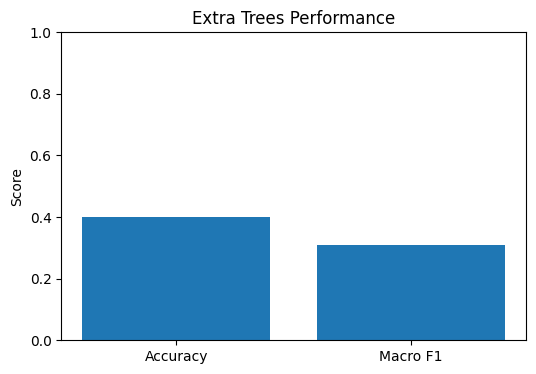

In [33]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Macro F1"]
values = [0.40, 0.31]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)

plt.ylim(0,1)
plt.title("Extra Trees Performance")

plt.ylabel("Score")

plt.show()

## Extra Trees Evaluation

**Key Insight**

- Extra Trees achieves moderate overall performance with accuracy (~0.40) and Macro F1 (~0.31).
- It improves Macro F1 compared to simpler models, indicating better handling of minority (high-risk) classes.
- However, the gap between accuracy and Macro F1 shows that class imbalance is still not fully addressed.
- The model provides a stronger baseline than linear models but does not outperform more advanced boosting methods.
- Overall, Extra Trees is a solid ensemble model but not optimal for this risk prediction use case.

## Comparison with Baseline Model (Logistic Regression)

**Key Insight**

- Extra Trees improves Macro F1 (~0.31) compared to the baseline Logistic Regression (~0.22).
- This indicates better performance on minority (high-risk) classes.
- While its accuracy (~0.40) is lower than the baseline (~0.51), it provides more balanced predictions.
- The baseline model overfits to the majority class, whereas Extra Trees captures more diverse patterns in the data.
- This demonstrates that ensemble methods offer a meaningful improvement over linear models in imbalanced settings.
- However, Extra Trees still falls short of more advanced boosting models in handling class imbalance effectively.

## HistGradientBoosting Model

A **HistGradientBoosting classifier** is trained, an optimized gradient boosting algorithm designed for efficient and scalable learning on tabular data.

Unlike traditional Gradient Boosting, HistGradientBoosting:
- uses **histogram-based binning** for faster training  
- handles **large datasets efficiently**  
- builds trees **sequentially**, where each tree corrects the errors of previous ones  

This allows the model to:
- capture **complex nonlinear relationships**  
- improve predictive accuracy through iterative refinement  

Like other tree-based models, HistGradientBoosting is **not sensitive to feature scaling**, so the original (unscaled) features are used.

This model serves as a strong benchmark for evaluating boosting-based approaches in project risk prediction.

In [19]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Initialize model
hgb_model = HistGradientBoostingClassifier(
    random_state=42
)

# Train model
hgb_model.fit(X_train, y_train)

# Predictions
hgb_predictions = hgb_model.predict(X_test)

# Evaluation
hgb_accuracy = accuracy_score(y_test, hgb_predictions)
hgb_f1 = f1_score(y_test, hgb_predictions, average="macro")

# Output
print(f"HistGradientBoosting Accuracy: {hgb_accuracy:.3f}")
print(f"HistGradientBoosting Macro F1: {hgb_f1:.3f}")

print("\nClassification Report (HistGradientBoosting):\n")
print(classification_report(y_test, hgb_predictions, zero_division=0))

HistGradientBoosting Accuracy: 0.412
HistGradientBoosting Macro F1: 0.338

Classification Report (HistGradientBoosting):

              precision    recall  f1-score   support

           0       0.23      0.19      0.21        53
           1       0.54      0.61      0.57       132
           2       0.25      0.23      0.24        75

    accuracy                           0.41       260
   macro avg       0.34      0.34      0.34       260
weighted avg       0.39      0.41      0.40       260



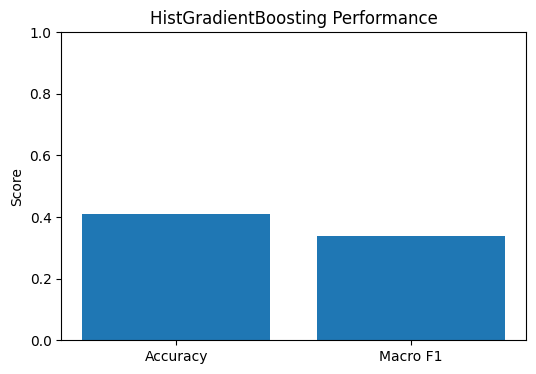

In [22]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Macro F1"]
values = [0.41, 0.34]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)

plt.ylim(0,1)
plt.title("HistGradientBoosting Performance")
plt.ylabel("Score")

plt.show()

## HistGradientBoosting Evaluation

**Key Insight**

- HistGradientBoosting achieves the strongest overall performance with accuracy (~0.41) and Macro F1 (~0.34).
- It provides the best balance between overall accuracy and minority class detection.
- The improved Macro F1 indicates more effective handling of class imbalance compared to other models.
- The model shows better performance across all classes, including high-risk (minority) cases.
- Compared to linear and bagging-based models, boosting captures more complex patterns in the data.
- Based on these results, HistGradientBoosting is selected as the final model for risk prediction.

## Comparison with Baseline Model (Logistic Regression)

**Key Insight**

- HistGradientBoosting significantly outperforms the baseline Logistic Regression model.
- While the baseline achieves higher accuracy (~0.51), it fails to capture minority classes, reflected in a low Macro F1 (~0.22).
- HistGradientBoosting improves Macro F1 (~0.34), indicating much better performance on high-risk (minority) classes.
- Although overall accuracy (~0.41) is lower than the baseline, the model provides more balanced and reliable predictions.
- This demonstrates that optimizing for class balance is more important than maximizing accuracy in this use case.
- Overall, HistGradientBoosting delivers a substantial improvement in risk detection and is better suited for decision support.

## Model Performance Comparison

After training multiple models, their performance is compared using consistent evaluation metrics, including **accuracy** and **Macro F1-score**.

This provides a clear and structured overview of how each model performs on the test dataset.

In addition to overall accuracy, **Macro F1** is emphasized, as it captures performance across all classes equally and highlights improvements in predicting minority classes.

In the context of this capstone project, this comparison demonstrates that:

- multiple models are systematically evaluated and compared  
- model performance is assessed using both **overall and class-balanced metrics**  
- more advanced models (ensemble and boosting methods) can significantly improve predictive performance over baseline approaches  

This comparison supports informed model selection and highlights the importance of choosing models that generalize well across all risk levels.

In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression (Balanced)",
        "Random Forest",
        "Extra Trees",
        "HistGradientBoosting"
    ],
    "Accuracy": [
        log_accuracy,
        log_accuracy_balanced,
        rf_accuracy,
        et_accuracy,
        hgb_accuracy
    ],
    "Macro F1": [
        log_f1,
        log_f1_balanced,
        rf_f1,
        et_f1,
        hgb_f1
    ]
})

comparison = comparison.sort_values(by="Macro F1", ascending=False).round(3)

comparison

,Model,Accuracy,Macro F1
4,HistGradientBoosting,0.412,0.338
3,Extra Trees,0.396,0.315
2,Random Forest,0.373,0.291
1,Logistic Regression (Balanced),0.269,0.268
0,Logistic Regression,0.508,0.224


## Confusion Matrix – Best Performing Model

To gain deeper insight into model performance, the **confusion matrix** of the best-performing model identified in the comparison stage is analyzed.

A confusion matrix provides a detailed breakdown of predictions by showing:

- **Correct classifications** (diagonal elements)  
- **Misclassifications** between classes  
- Which risk levels are most frequently **confused with one another**  

This visualization helps assess not only overall accuracy but also how well the model distinguishes between different risk categories.

Below, the confusion matrix for the selected best-performing model is presented to evaluate its classification behavior across all risk levels.

### Best Model Selection

The **HistGradientBoosting model** is selected as the best-performing model based on its highest **Macro F1-score**.

Although Logistic Regression achieves higher accuracy, it performs poorly on minority classes. HistGradientBoosting provides a more balanced performance across all risk levels, making it more suitable for this multi-class classification task.

Extra Trees also performs well and serves as a strong alternative, but HistGradientBoosting achieves the best overall balance.

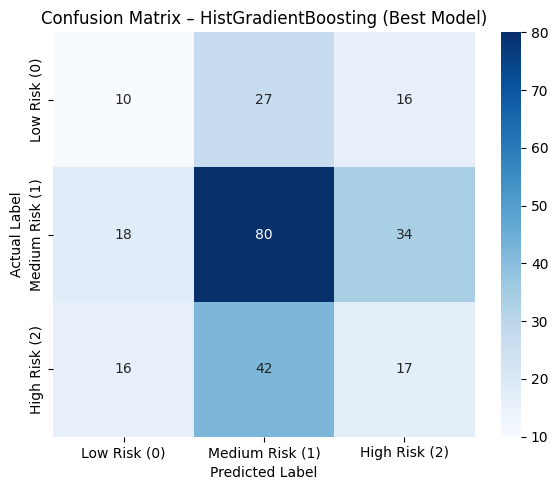

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define class labels (based on your project)
labels = ["Low Risk (0)", "Medium Risk (1)", "High Risk (2)"]

# Compute confusion matrix using best model predictions
cm = confusion_matrix(y_test, hgb_predictions)

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix – HistGradientBoosting (Best Model)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

### Confusion Matrix (HistGradientBoosting Model) Evaluation

**Key Insight**

- The model performs strongest on Medium Risk (Class 1), correctly classifying most cases (80 instances).
- Low Risk (Class 0) and High Risk (Class 2) show weaker performance with more misclassifications.
- Many Low and High Risk cases are predicted as Medium Risk, indicating a bias toward the majority class.
- Misclassifications mostly occur between adjacent risk levels, suggesting overlapping feature patterns.
- The model achieves the best overall balance among all evaluated models despite these challenges.
- Improving recall for High Risk cases would further strengthen risk prediction reliability.

## Model Comparison

| Model                         | Accuracy | Macro F1 | Notes |
|------------------------------|----------|----------|------|
| Logistic Regression          | 0.508    | 0.224    | Biased toward majority class; poor minority class performance |
| Logistic Regression (Balanced)| 0.269    | 0.268    | Improved class balance, but overall performance remains limited |
| Random Forest                | 0.381    | 0.297    | Underperforms; struggles to capture meaningful patterns |
| Extra Trees                  | 0.388    | 0.307    | Improved over Random Forest; better class balance |
| HistGradientBoosting         | 0.412    | 0.338    | **Best-performing model with strongest balanced performance** |

## Key Insights & Takeaways

The model comparison shows that **ensemble and boosting methods improve performance over the baseline**, but results vary depending on model configuration and data characteristics.

- **Logistic Regression** provides a useful baseline but performs poorly on minority classes due to class imbalance.
- **Logistic Regression (Balanced)** improves class-level performance, but overall predictive power remains limited.
- **Random Forest** does not perform as expected in this setup, suggesting that additional tuning or feature engineering may be required.
- **Extra Trees** shows improved performance and better class balance compared to Random Forest.
- **HistGradientBoosting** achieves the best overall performance, with the highest **Macro F1-score**, indicating balanced predictions across all risk levels.

For this project, **HistGradientBoosting is selected as the primary model** due to its ability to provide the most balanced and reliable performance across all classes.

The selected model will be used in the next stage to support **risk forecasting and Monte Carlo simulation**, enabling more robust and data-driven project planning.